This notebook can load and open raw czi images (and draw ROI masks), load mask file (tiff), calculate thresholds for each channel, extract fluorescence signals in each ROI in each channel, and save the values in csv. It then split the original csv into a L and R half and then reorder to center the axonal glomerulus, and save the 2 reordered csv into the "reordered" folder. csv in the "reordered" folder will be used for future analysis.

NOTE: For the threshold, this notebook allows different percentile for the red channel for different flies (the percentile for the green channel should be the same for all the flies).

In [16]:
import sys
from pathlib import Path
import importlib

# Add library folder to Python path
project_root = Path.cwd().parent
library_path = project_root / "library"

if str(library_path) not in sys.path:
    sys.path.append(str(library_path))

import lib_get_signal_from_airyscan as airyscan
importlib.reload(airyscan)

import os
import math

import numpy as np
import pandas as pd
import xarray as xr

# Image I/O
import napari
from aicsimageio import AICSImage
from skimage import io, measure
from skimage.measure import regionprops_table
import tifffile as tf
import tifftools
import czifile
from czifile import CziFile
from PIL import Image
import imageio

# Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# for the "reorder" section
import re

from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
from matplotlib.patches import Patch
from typing import Dict, Iterable

# for downloading as png/svg
import imageio.v3 as iio
from napari.utils.colormaps import Colormap
from matplotlib.colors import LinearSegmentedColormap



In [2]:
# Add config folder to path. This is where we store paths to the raw images, manually defined label masks, and z-ranges.
config_path = project_root / "configs"

if str(config_path) not in sys.path:
    sys.path.append(str(config_path))

import airyscan_config as config
importlib.reload(config)

images = config.images
label_masks = config.label_masks
label_masks_checking = config.label_masks_checking
z_ranges_by_fly = config.z_ranges_by_fly

In [9]:
current_fly = "fly17"   # <-- switch here

In [10]:
# load the image and the channels into separate variables.
assets_image = airyscan.load_fly(
    current_fly,
    images=images,
    red_idx=1,
    green_idx=2,
    blue_idx=0,)
red_channel = assets_image["red_channel"]
green_channel = assets_image["green_channel"]
blue_channel = assets_image["blue_channel"]

In [12]:
# open image in napari to draw labels. NOTE: the contrast_limits can be changed, but I fixed them for consistency across all flies.
viewer = napari.Viewer()

# Add the red channel
viewer.add_image(
    red_channel, 
    name='568 Channel',
    colormap='red',
    contrast_limits=(0, 1000), # adjust this if needed
    blending='additive'
)
# Add the green channel
viewer.add_image(
    green_channel, 
    name='488 Channel',
    colormap='green',
    contrast_limits=(0, 800), # adjust this if needed
    blending='additive'
)

# Add the blue channel
viewer.add_image(
    blue_channel, 
    name='633 Channel',
    colormap='blue',
    #contrast_limits=(50, 800), # adjust this if needed
    blending='additive'
)

napari.run()

In [129]:
# load the label mask and the z ranges for this fly.
assets_label = airyscan.load_fly_mask(
    current_fly,
    label_masks=label_masks,
    label_masks_checking=label_masks_checking,
    require_masks=True,)
label_mask = assets_label["label_mask"]
label_mask_checking = assets_label["label_mask_checking"]
print("Label mask shape:", label_mask.shape)
print("Green channel shape:", green_channel.shape)
print("Red channel shape:", red_channel.shape)
Z = assets_image["shape"][1]
z_ranges = airyscan.get_z_ranges(
    current_fly,
    z_ranges_by_fly=z_ranges_by_fly,
    Z=Z,
    clip=False,)

# check which z stack I drew the label on.
sums = label_mask.sum(axis=(1,2))
painted_slices = np.where(sums > 0)[0]
print("You painted on slice(s):", painted_slices)

Label mask shape: (153, 1839, 1839)
Green channel shape: (153, 1839, 1839)
Red channel shape: (153, 1839, 1839)
You painted on slice(s): [74]


In [ ]:
# Reopen the original image and masks in napari to redraw/check the masks

viewer = napari.Viewer()

viewer.add_image(blue_channel,  name="Blue (raw)",  colormap="blue",  blending="additive", visible=False)
viewer.add_image(green_channel, name="Green (raw)", colormap="green", blending="additive", visible=True)
viewer.add_image(red_channel,   name="Red (raw)",   colormap="red",   blending="additive", visible=True)

viewer.add_labels(label_mask.astype(np.int32), name="Labels", opacity=0.5)
viewer.add_labels(label_mask_checking.astype(np.int32), name="Labels-bg", opacity=0.5)

napari.run()

# get the correct threshold (one per z slice)

In [138]:
importlib.reload(config)
q_by_fly = config.q_by_fly
q_rg = q_by_fly[current_fly]

In [ ]:
q_rg

(0.975, 0.95)

: 

''' This is the old code.
This function gets the "percentiled" threshold FOR EACH Z SLICE within that one huge background roi i draw, the red and green threshold is define differently (using different threshold)
'''
df_thresholds = airyscan.per_slice_percentiles_red_and_green_diff(
    red_channel=red_channel,
    green_channel=green_channel,
    label_mask_checking=label_mask_checking,
    q=q_by_fly[current_fly],
    roi_id=1,
    exclude_zero=False,
)
df_thresholds

In [134]:
# this cell uses the most general function of per_slice_percentiles, which can handle any number of channels and separate background ROIs for each channel. Here, I use the same background ROI for red and green channels, and the q from airyscan_config for both channels.
# I also include threshold for blue channel, in case we want to use that in the future, even though we don't have a background ROI for it (so it will just use the whole image as background for blue channel for now).
# only fly17 has background ROI for blue, for now.

q_by_channel = {
    "red": q_rg[0],             # <-- change here and below to do sensitivity analysis.
    "green": q_rg[1],
    "blue": 0.95,               # <-- change to another number, or q_rg[2] if we save the percentile for blue in the config.
}

roi_id_by_channel = {
    "red": 1,
    "green": 1,
    "blue": 2,
}
df_thresholds = airyscan.per_slice_percentiles_by_channel(
    channels={
        "red": red_channel,
        "green": green_channel,
        "blue": blue_channel,
    },
    label_mask_checking=label_mask_checking,
    q_by_channel=q_by_channel,
    roi_id_by_channel=roi_id_by_channel,
    exclude_zero=False,
    round_pct=1,
)
df_thresholds

,z,red_roi_id,red_roi_pixels,red_threshold,red_frac_leq_pct,red_percentile_q,green_roi_id,green_roi_pixels,green_threshold,green_frac_leq_pct,green_percentile_q,blue_roi_id,blue_roi_pixels,blue_threshold,blue_frac_leq_pct,blue_percentile_q
0,0,1,146751,704.0,99.5,1.0,1,146751,341.0,95.0,0.9,2,15533,180.0,95.1,0.9
1,1,1,146751,672.0,99.5,1.0,1,146751,338.5,95.0,0.9,2,15533,170.0,95.0,0.9
2,2,1,146751,636.0,99.5,1.0,1,146751,329.0,95.0,0.9,2,15533,163.0,95.1,0.9
3,3,1,146751,619.0,99.5,1.0,1,146751,326.0,95.0,0.9,2,15533,160.0,95.1,0.9
4,4,1,146751,663.2,99.5,1.0,1,146751,329.0,95.0,0.9,2,15533,163.0,95.1,0.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,148,1,146751,178.0,99.5,1.0,1,146751,125.0,95.0,0.9,2,15533,202.0,95.1,0.9
149,149,1,146751,176.0,99.5,1.0,1,146751,123.0,95.0,0.9,2,15533,207.0,95.0,0.9
150,150,1,146751,172.0,99.5,1.0,1,146751,122.0,95.2,0.9,2,15533,211.0,95.1,0.9
151,151,1,146751,166.0,99.5,1.0,1,146751,120.0,95.2,0.9,2,15533,217.0,95.2,0.9


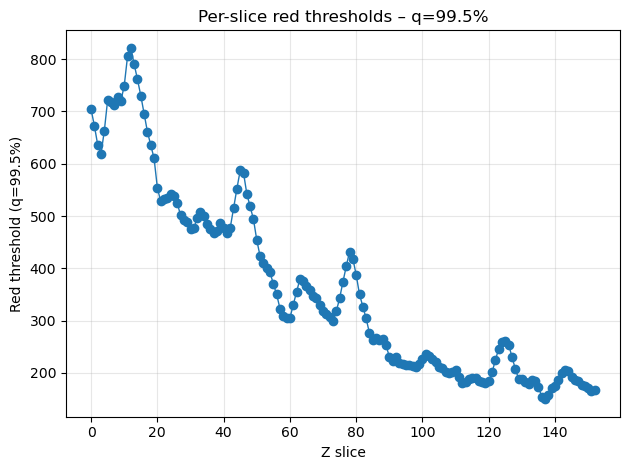

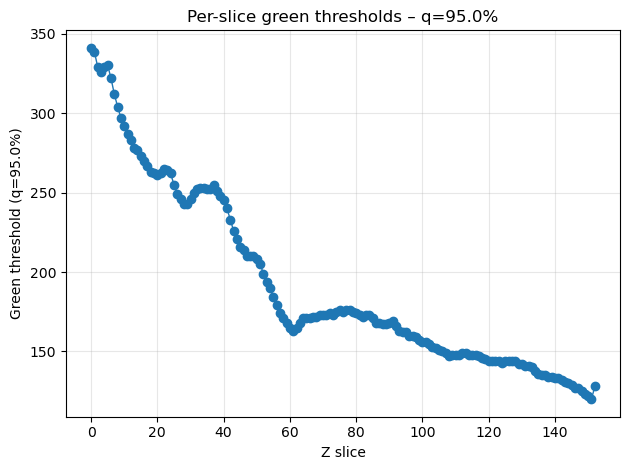

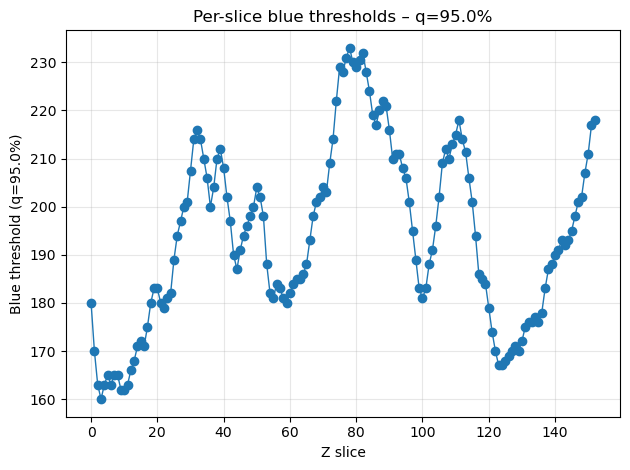

In [135]:
# visusalize the thresholds trend with graphs.
importlib.reload(airyscan)
airyscan.plot_per_slice_thresholds_rgb(df_thresholds)

# visualize the masks in napari as a final check before extracting the signals

In [136]:
importlib.reload(airyscan)
# Build threshold masks and visualize them in napari to check whether thresholds are reasonable

threshold_masks = airyscan.build_threshold_masks_per_roi(
    red_channel=red_channel,
    green_channel=green_channel,
    label_mask=label_mask,
    z_ranges=z_ranges,
    df_thresholds=df_thresholds,
)

mask_red_labels = threshold_masks["mask_red_labels"]
mask_green_full = threshold_masks["mask_green_full"]

viewer = napari.Viewer()

# raw channels
viewer.add_image(red_channel,   name='Red (raw)',   colormap='red',   contrast_limits=(0, 500), blending='additive')
viewer.add_image(green_channel, name='Green (raw)', colormap='green', contrast_limits=(0, 500), blending='additive', visible=False)

# mask_red as LABELS → default napari per-label coloring (each ROI a different color)
viewer.add_labels(mask_red_labels, name='Mask – red per ROI (per-Z thresh)', opacity=0.6)

# mask_green as IMAGE → solid green binary overlay (subset of red)
viewer.add_image(mask_green_full.astype(np.float32), name='Mask – green subset (per-Z thresh)',
                 colormap='red', blending='additive', opacity=0.7, visible=False)
# add blue channel
viewer.add_image(blue_channel,  name='Blue (raw)',  colormap='blue',  blending='additive', visible=False)
# optionally also show your original ROI labels
# viewer.add_labels(label_mask.astype(np.int32), name='ROI labels (drawn)', opacity=0.25)

napari.run()

# get the final df ("mean" and "total" signal)
by the end of this section, both split and non-split* flies should have all glomeruli into one df, named df_means as a global notbook variable.

*split flies: wasn't able to capture all 18 glomeruli into one image, so split this fly's brain into a left side and a right side.

In [52]:
importlib.reload(airyscan)
# Extract per-ROI red and green signal using per-z-slice thresholds

pd.set_option("display.float_format", lambda v: f"{v:.1f}")

df_means = airyscan.extract_roi_signal_with_per_z_thresholds(
    red_channel=red_channel,
    green_channel=green_channel,
    label_mask=label_mask,
    z_ranges=z_ranges,
    df_thresholds=df_thresholds,
)

df_means

,mean_red,mean_green,total_red,total_green
1,600.1,312.7,230023447.0,32117557.0
2,832.0,336.0,852960397.0,97966120.0
3,664.5,330.0,453305916.0,60375731.0
4,505.2,340.0,289708849.0,37973759.0
5,376.3,278.2,226715223.0,19097229.0
6,332.6,269.9,150113611.0,14619476.0
7,903.1,326.4,1801818847.0,166100848.0
8,359.5,282.5,242564280.0,15385949.0
9,434.5,276.4,368929242.0,32762558.0
10,478.8,287.6,550693398.0,47370682.0


# choice 1

In [ ]:
q_folder = "q_around99"             # <-- change here if use another percentile. q_around99 means different red percentiles for different files.


results_dir = project_root / "results" / "extracted_signals" / q_folder / 'original'
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / f"{current_fly}.csv"
df_means.to_csv(output_path, index=True)
print("Saved to:", output_path)

Saved to: /Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/results/extracted_signals/q_around99/original/fly17.csv


# choice 2

In [46]:
# this cell is for when one brain is split into 2 images, and need to have the values combined into one csv... (manually combine both dfs...)
# DO NOT USE THIS CELL IF THIS FLY IS NOT SPLIT INTO 2 IMAGES.

data = {
    "mean_red": [
        567.4, 853.8, 703.1, 579.3, 453.2, 1296.4,
        417.0, 416.3, 459.3, 594.8, 624.9, 552.7,
        527.2, 1223.7, 747.4, 919.5, 1062.0, 1000.6
    ],
    "mean_green": [
        281.8, 253.1, 249.5, 222.4, 182.1, 179.3,
        136.3, 158.3, 162.3, 152.9, 170.1, 175.6,
        177.6, 222.0, 226.7, 248.2, 250.8, 318.4
    ],
    "total_red": [
        114767358, 1053884314, 1246013685, 1145191560, 557912638, 3621776611,
        402121259, 412636611, 501260198, 936361932, 1303666875, 1115187397,
        789344824, 5373641910, 1225537433, 1706320570, 1555077365, 460508439
    ],
    "total_green": [
        8014225, 44939897, 54519721, 49060185, 16852201, 215974917,
        10167728, 17996307, 25497540, 34949774, 65062305, 56370049,
        32227989, 255184867, 51379765, 95521980, 82738544, 36879424
    ],
}
df_means = pd.DataFrame(data, index=range(1, 19))

In [1]:
# Save this manually combined df to CSV
# DO NOT USE THIS CELL IF THIS FLY IS NOT SPLIT INTO 2 IMAGES.
q_folder = "q_around99"             # <-- change here if use another percentile. q_around99 means different red percentiles for different files.

save_dir = project_root / "results" / "extracted_signals" / q_folder / 'original'
save_dir.mkdir(parents=True, exist_ok=True)
output_path = save_dir / "fly14.csv"
df_means.to_csv(output_path)
print("Saved to:", output_path)

NameError: name 'project_root' is not defined

'''This cell is to measure how much green is on high enough blue values.'''
df_blue = airyscan.extract_rg_and_blue_on_green_pixels_exact_old_logic(
    red_channel=red_channel,
    green_channel=green_channel,
    blue_channel=blue_channel,
    label_mask=label_mask,
    df_thresholds=df_thresholds,
    z_ranges=z_ranges,
)

df_blue

'''This cell is to visualize how much green is on high enough blue values.'''

airyscan.plot_one_column_across_rois(
    df_blue,
    "percent_blue_positive_on_green_pixels",
    xlabel="ROI",
    ylabel="% blue-positive among green pixels",
    title="Blue-positive fraction across ROIs",
    ylim=(0, 100)
)

'''this cell opens the image and the masks together, so that i can check whether
the thresholds i set are reasonable, now including blue mask as image.
'''
rgb_masks = airyscan.build_rgb_threshold_masks_per_roi(
    red_channel=red_channel,
    green_channel=green_channel,
    blue_channel=blue_channel,
    label_mask=label_mask,
    z_ranges=z_ranges,
    df_thresholds=df_thresholds,
)

mask_red_labels = rgb_masks["mask_red_labels"]
mask_green_full = rgb_masks["mask_green_full"]
mask_blue_full = rgb_masks["mask_blue_full"]

viewer = napari.Viewer()

viewer.add_image(
    red_channel,
    name="Red (raw)",
    colormap="red",
    contrast_limits=(0, 500),
    blending="additive",
)

viewer.add_image(
    green_channel,
    name="Green (raw)",
    colormap="green",
    contrast_limits=(0, 500),
    blending="additive",
    visible=False,
)

viewer.add_image(
    blue_channel,
    name="Blue (raw)",
    colormap="blue",
    blending="additive",
    visible=False,
)

viewer.add_labels(
    mask_red_labels,
    name="Mask – red per ROI (per-Z thresh)",
    opacity=0.6,
)

viewer.add_image(
    mask_green_full.astype(np.float32),
    name="Mask – green subset (per-Z thresh)",
    colormap="green",
    blending="additive",
    opacity=0.7,
    visible=False,
)

viewer.add_image(
    mask_blue_full.astype(np.float32),
    name="Mask – blue on green subset (per-Z thresh)",
    colormap="blue",
    blending="additive",
    opacity=0.7,
    visible=False,
)

napari.run()

# reorder the original df_means
first, split each cell into a L and R side,

then, reorder to put the axonal glomerulus at center (index=5),

finally, save the reordered df to the "reordered" folder to prepare it to do future analysis

In [73]:
importlib.reload(config)
glomeruli = config.glomeruli
fly_subtype = config.fly_subtype

In [79]:
# Add glomerulus labels and keep columns needed for trend analysis

df_means_glom = df_means.copy()
df_means_glom = df_means_glom.assign(glomerulus=glomeruli)[
    ["glomerulus", "mean_red", "mean_green", "total_red", "total_green"]
]

df_means_glom

,glomerulus,mean_red,mean_green,total_red,total_green
1,L9,600.1,312.7,230023447.0,32117557.0
2,L8,832.0,336.0,852960397.0,97966120.0
3,L7,664.5,330.0,453305916.0,60375731.0
4,L6,505.2,340.0,289708849.0,37973759.0
5,L5,376.3,278.2,226715223.0,19097229.0
6,L4,332.6,269.9,150113611.0,14619476.0
7,L3,903.1,326.4,1801818847.0,166100848.0
8,L2,359.5,282.5,242564280.0,15385949.0
9,L1,434.5,276.4,368929242.0,32762558.0
10,R1,478.8,287.6,550693398.0,47370682.0


In [80]:
flies_without_L9 = {"fly1", "fly3", "fly8", "fly15"}

if current_fly in flies_without_L9:
    mask = df_means_glom["glomerulus"] == "L9"

    df_means_glom.loc[mask, ["total_green", "total_red", "mean_red", "mean_green"]] = 0

In [70]:
current_subtype = fly_subtype[current_fly]
current_parts = airyscan.subtype_to_part_dict(current_subtype)

part1 = current_parts["part1"]
part2 = current_parts["part2"]

current_subtype, current_parts

('L3R6', {'part1': 'L3', 'part2': 'R6'})

In [81]:
df_left, df_right = airyscan.split_df_into_left_right_halves(df_means_glom)

df_left, df_right

(  glomerulus  mean_red  mean_green    total_red  total_green
 0         L9     600.1       312.7  230023447.0   32117557.0
 1         L8     832.0       336.0  852960397.0   97966120.0
 2         L7     664.5       330.0  453305916.0   60375731.0
 3         L6     505.2       340.0  289708849.0   37973759.0
 4         L5     376.3       278.2  226715223.0   19097229.0
 5         L4     332.6       269.9  150113611.0   14619476.0
 6         L3     903.1       326.4 1801818847.0  166100848.0
 7         L2     359.5       282.5  242564280.0   15385949.0
 8         L1     434.5       276.4  368929242.0   32762558.0,
   glomerulus  mean_red  mean_green    total_red  total_green
 0         R1     478.8       287.6  550693398.0   47370682.0
 1         R2     521.4       301.3  748680412.0   64753642.0
 2         R3     467.6       301.6  669577671.0   89078596.0
 3         R4     500.7       312.5  479200296.0   72659945.0
 4         R5     480.2       276.2  264299347.0   28580639.0
 5     

In [82]:
# combine 1 and 9 glomerulus, and then take the average of the two.
df_left_combine19 = airyscan.combine_1_9(df_left)
df_right_combine19 = airyscan.combine_1_9(df_right)

df_left_combine19, df_right_combine19

(  glomerulus  mean_red  mean_green    total_red  total_green
 0       L1+9     517.3       294.5  598952689.0   64880115.0
 1         L8     832.0       336.0  852960397.0   97966120.0
 2         L7     664.5       330.0  453305916.0   60375731.0
 3         L6     505.2       340.0  289708849.0   37973759.0
 4         L5     376.3       278.2  226715223.0   19097229.0
 5         L4     332.6       269.9  150113611.0   14619476.0
 6         L3     903.1       326.4 1801818847.0  166100848.0
 7         L2     359.5       282.5  242564280.0   15385949.0,
   glomerulus  mean_red  mean_green    total_red  total_green
 0       R1+9     748.3       416.9  922931330.0  104438017.0
 1         R2     521.4       301.3  748680412.0   64753642.0
 2         R3     467.6       301.6  669577671.0   89078596.0
 3         R4     500.7       312.5  479200296.0   72659945.0
 4         R5     480.2       276.2  264299347.0   28580639.0
 5         R6    1467.6       435.9 2690139984.0  312062293.0
 6     

In [84]:
# reorder the halves so that the axonal glomerulus is in the middle (index 4).
df_left_reordered = airyscan.reorder_half_to_center(
    df_left_combine19,
    center=part1,
    target_idx=4,
)

df_right_reordered = airyscan.reorder_half_to_center(
    df_right_combine19,
    center=part2,
    target_idx=4,
)

df_left_reordered, df_right_reordered

(  glomerulus  mean_red  mean_green    total_red  total_green
 0         L7     664.5       330.0  453305916.0   60375731.0
 1         L6     505.2       340.0  289708849.0   37973759.0
 2         L5     376.3       278.2  226715223.0   19097229.0
 3         L4     332.6       269.9  150113611.0   14619476.0
 4         L3     903.1       326.4 1801818847.0  166100848.0
 5         L2     359.5       282.5  242564280.0   15385949.0
 6       L1+9     517.3       294.5  598952689.0   64880115.0
 7         L8     832.0       336.0  852960397.0   97966120.0,
   glomerulus  mean_red  mean_green    total_red  total_green
 0         R2     521.4       301.3  748680412.0   64753642.0
 1         R3     467.6       301.6  669577671.0   89078596.0
 2         R4     500.7       312.5  479200296.0   72659945.0
 3         R5     480.2       276.2  264299347.0   28580639.0
 4         R6    1467.6       435.9 2690139984.0  312062293.0
 5         R7     764.7       353.1  378620963.0   38617586.0
 6     

In [86]:
# add a wrapped row to the bottom of the df, which is a copy of the top row, so there are still 9 glomeruli and the axonal glomerulus will be in the center. 
df_left_add1row = airyscan.add_wrapped_row(df_left_reordered)
df_right_add1row = airyscan.add_wrapped_row(df_right_reordered)

df_left_add1row, df_right_add1row

(  glomerulus mean_red mean_green    total_red total_green
 0         L7    664.5      330.0  453305916.0  60375731.0
 1         L6    505.2      340.0  289708849.0  37973759.0
 2         L5    376.3      278.2  226715223.0  19097229.0
 3         L4    332.6      269.9  150113611.0  14619476.0
 4         L3    903.1      326.4 1801818847.0 166100848.0
 5         L2    359.5      282.5  242564280.0  15385949.0
 6       L1+9    517.3      294.5  598952689.0  64880115.0
 7         L8    832.0      336.0  852960397.0  97966120.0
 8      added    664.5      330.0  453305916.0  60375731.0,
   glomerulus mean_red mean_green    total_red total_green
 0         R2    521.4      301.3  748680412.0  64753642.0
 1         R3    467.6      301.6  669577671.0  89078596.0
 2         R4    500.7      312.5  479200296.0  72659945.0
 3         R5    480.2      276.2  264299347.0  28580639.0
 4         R6   1467.6      435.9 2690139984.0 312062293.0
 5         R7    764.7      353.1  378620963.0  3861758

In [90]:
# save the reodered halves.
subfolder = "reordered"
results_dir = project_root / "results" / "extracted_signals" / q_folder / subfolder
results_dir.mkdir(parents=True, exist_ok=True)

df_left_add1row.to_csv(results_dir / f"{current_fly}_L.csv", index=False)
df_right_add1row.to_csv(results_dir / f"{current_fly}_R.csv", index=False)

print(f"Saved files to: {results_dir}")

Saved files to: /Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/results/extracted_signals/q_around99/reordered


# find the percentile

Global Z range (clipped): 8..152 (from raw 8..152, Z=153)
Red   99.000th pct = 607 | fraction ≤ line: 99.00%
Green 95.000th pct = 199 | fraction ≤ line: 95.00%


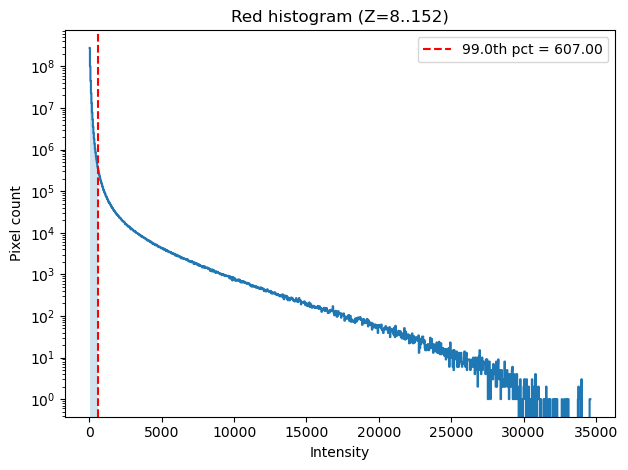

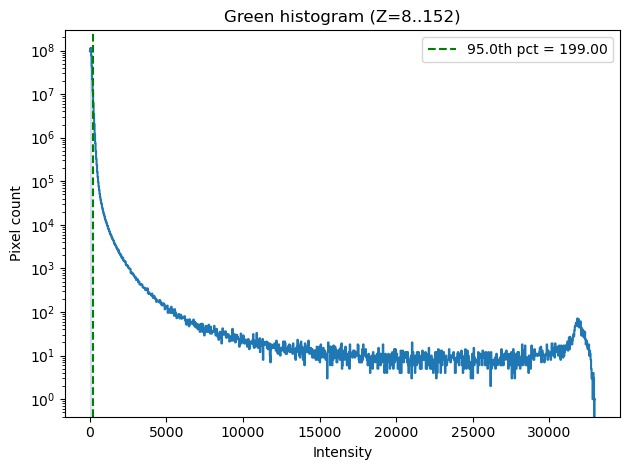

In [115]:
hist_info = airyscan.plot_intensity_histograms_with_percentile(
    red_channel=red_channel,
    green_channel=green_channel,
    z_ranges=z_ranges,
    q_by_channel={"red": 0.99, "green": 0.95},
    bins=1024,
    exclude_zero=False,
    use_dtype_range=False,
)

In [117]:
importlib.reload(airyscan)

<module 'lib_get_signal_from_airyscan' from '/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_get_signal_from_airyscan.py'>

Global Z range (clipped): 8..152 (from raw 8..152, Z=153)


(     q  q_percent  threshold  fraction_leq  fraction_leq_percent
 0  0.6       60.0       37.0           0.6                  60.1
 1  0.7       65.0       44.0           0.7                  65.3
 2  0.7       70.0       52.0           0.7                  70.3
 3  0.8       75.0       62.0           0.8                  75.2
 4  0.8       80.0       76.0           0.8                  80.3
 5  0.8       85.0       95.0           0.9                  85.1
 6  0.9       90.0      127.0           0.9                  90.0
 7  0.9       95.0      199.0           1.0                  95.0
 8  1.0       97.5      308.0           1.0                  97.5
 9  1.0       99.0      607.0           1.0                  99.0
 10 1.0       99.5     1123.0           1.0                  99.5,
      q  q_percent  threshold  fraction_leq  fraction_leq_percent
 0  0.0        1.0        0.0           0.0                   4.2
 1  0.3       30.0       49.0           0.3                  30.4
 2  0.6  

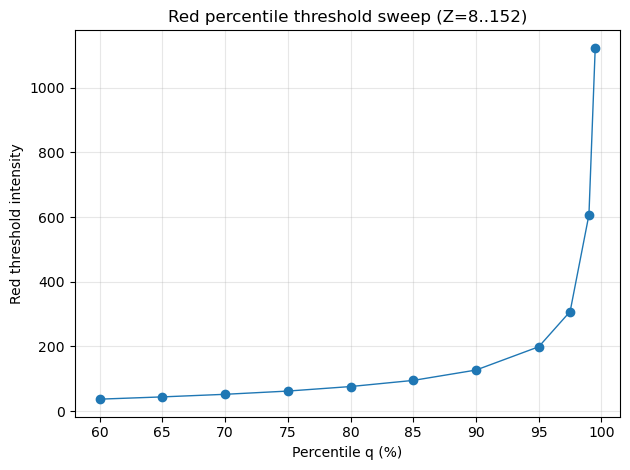

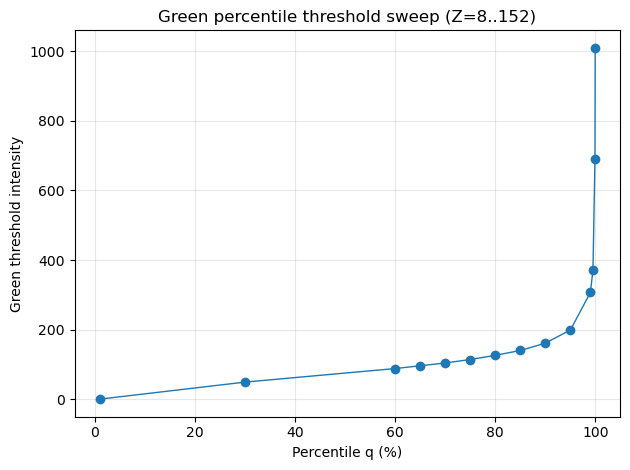

In [125]:
q_sweep = airyscan.plot_percentile_threshold_sweep_by_channel(
    red_channel=red_channel,
    green_channel=green_channel,
    z_ranges=z_ranges,
    q_values_by_channel={
        "red": [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.975,0.99, 0.995],
        "green": [0.01, 0.30, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 0.995, 0.999, 0.9995],
    },
    exclude_zero=False,
)

q_sweep["red"], q_sweep["green"]

# save images as png

fly10:
- tdt
contrast_limits=(600, 2500),
- gfp
contrast_limits=(700, 4500),

fly6:
- tdt
contrast_limits=(500, 4500), (blue: (500, 3500))
- gfp
contrast_limits=(500, 3000),


load image method 1: not in config

In [15]:
current_fly = "/Users/fisherguest/Documents/sansa images/09062025/SC-0906-fly10.czi"   # <-- switch here

In [16]:
# import image:
img = AICSImage(current_fly)

# Get the data in (C, Z, Y, X)
# C: Channels (e.g., the different lasers/fluorophores); Z: Z-stacks (slices in depth); Y and X: The spatial dimensions (height and width)
# i don't have S or T.
data = img.get_image_data("CZYX", S=0, T=0)

# checked using "previous TQ method": 568 is first (now second) channel, 488 is second (now third) channel.
red_channel   = data[1]
green_channel = data[2]
#blue_channel = data[0]

load image method 2: in config

In [3]:
# or
current_fly = "fly6"
assets_image = airyscan.load_fly(
    current_fly,
    images=images,
    red_idx=1,
    green_idx=2,
    blue_idx=0,)
red_channel = assets_image["red_channel"]
green_channel = assets_image["green_channel"]
blue_channel = assets_image["blue_channel"]

try the colors

notes: in order for the 2 colors to have a additive effect (generate a new color when 2 colors overlap), you need to have the RBG of the 2 colors add up to (1, 1, 1).

In [41]:
import matplotlib.pyplot as plt

def preview_color(rgb):
    """
    Preview an RGB color.

    Parameters
    ----------
    rgb : tuple or list
        RGB values between 0 and 1.
    """
    fig, ax = plt.subplots(figsize=(2, 2))
    ax.imshow([[rgb]])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

In [19]:
def preview_napari_colors(*colormaps):
    """
    Preview the endpoint color of one or more Napari Colormaps.

    Parameters
    ----------
    *colormaps : napari.utils.colormaps.Colormap
        One or more Napari Colormap objects.
    """

    n = len(colormaps)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))

    if n == 1:
        axes = [axes]

    for ax, cmap in zip(axes, colormaps):

        # last color = maximum intensity color
        rgb = cmap.colors[-1][:3]

        ax.imshow([[rgb]])
        ax.set_title(cmap.name, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

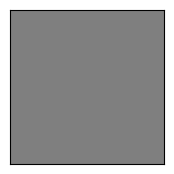

In [44]:
preview_color((0.5, 0.5, 0.5))

In [155]:
my_tdt = Colormap(
    colors=[
        [0, 0, 0, 1],          # black for zero intensity
        [0.6, 0.2, 0.3, 1],
    ],
    name="my_tdt",
)

my_glucl = Colormap(
    colors=[
        [0, 0, 0, 1],          # black for zero intensity
        [0.4, 0.8, 0.7, 1],
    ],
    name="my_glucl",
)

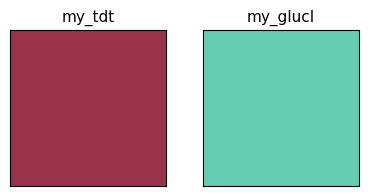

In [156]:
preview_napari_colors(my_tdt, my_glucl)

saved good combination:

customized_1: tdt: (0, 0.1, 0.6). glucl: (1, 0.9, 0.4) --- blue membrane too dark

customized_2: tdt: (0, 0.5, 0.8). glucl: (1, 0.5, 0.2) --- orange dots too dark

customized_2: tdt: (0, 0.3, 0.8). glucl: (1, 0.7, 0.2) --- orange dots still too dark

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


(-0.5, 8207.5, 7719.5, -0.5)

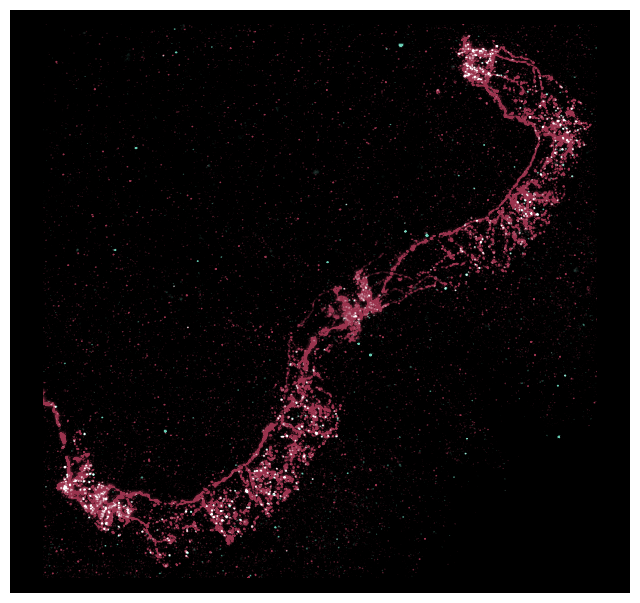

In [157]:
with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name='568 Channel',
        colormap=my_tdt,
        blending='additive',
        contrast_limits=(500, 3500),
        rendering='mip',
        #attenuation=0.05,
    )
    viewer.add_image(
        green_channel,
        name='488 Channel',
        colormap=my_glucl,
        blending='additive',
        contrast_limits=(500, 3000),
        rendering='mip',
    )

    # 2) Grab a *4× larger* screenshot of just the 3D canvas:
    highres = viewer.screenshot(canvas_only=True, scale=4)

# 3) Embed in a Matplotlib fig and save:
fig, ax = plt.subplots(figsize=(8, 8))   # size in inches is arbitrary
ax.imshow(highres, interpolation='nearest')
ax.axis('off')

save below

In [38]:
with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name='568 Channel',
        colormap=my_tdt,
        blending='additive',
        contrast_limits=(500, 3500),
        rendering='mip',
        #attenuation=0.05,
    )
    viewer.add_image(
        green_channel,
        name='488 Channel',
        colormap=my_glucl,
        blending='additive',
        contrast_limits=(500, 3000),
        rendering='mip',
    )

    # 2) Grab a *4× larger* screenshot of just the 3D canvas:
    highres = viewer.screenshot(canvas_only=True, scale=4)

# 3) Embed in a Matplotlib fig and save:
fig, ax = plt.subplots(figsize=(8, 8))   # size in inches is arbitrary
ax.imshow(highres, interpolation='nearest')
ax.axis('off')

# choose output folder
output_dir = project_root / "results" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / f"fly6_2channels.png",
    format="png",
    bbox_inches="tight",
    pad_inches=0,
    dpi=800,
)
plt.close(fig)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


In [51]:
# tdt channel

with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name="568 Channel",
        colormap=my_tdt,
        blending="additive",
        contrast_limits=(500, 3500),
        rendering="mip",
    )

    highres = viewer.screenshot(canvas_only=True, scale=4)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(highres, interpolation="nearest")
ax.axis("off")


output_dir = project_root / "results" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "fly6_568channel.png",
    format="png",
    bbox_inches="tight",
    pad_inches=0,
    dpi=800,
)
plt.close(fig)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


In [52]:
# GluCl channel

with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        green_channel,
        name="488 Channel",
        colormap=my_glucl,
        blending="additive",
        contrast_limits=(500, 3000),
        rendering="mip",
    )

    highres = viewer.screenshot(canvas_only=True, scale=4)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(highres, interpolation="nearest")
ax.axis("off")

output_dir = project_root / "results" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "fly6_488channel.png",
    format="png",
    bbox_inches="tight",
    pad_inches=0,
    dpi=800,
)
plt.close(fig)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()
